# Sprint 13 - Lógica Difusa (Sesiones)

En el presente caso de estudio exploraremos una aproximación diferente al aprendizaje computacional tradicional mediante el uso de la **lógica difusa**. A diferencia de muchos modelos de aprendizaje automático que requieren grandes volúmenes de datos históricos para aprender patrones y realizar predicciones, la **lógica difusa** se basa en la representación del conocimiento humano mediante reglas y conceptos lingüísticos. Su objetivo por tanto es modelar situaciones donde la información disponible es imprecisa, ambigua o difícil de expresar mediante valores numéricos exactos.

En numerosos problemas del mundo real no siempre es posible describir una situación utilizando únicamente números precisos. Con frecuencia, las personas toman decisiones basadas en percepciones, experiencias y criterios subjetivos expresados mediante términos como "alto", "bajo", "rápido", "lento", "cerca", "lejos" o "riesgoso". Aunque estos conceptos resultan naturales para los seres humanos, representan un desafío para los modelos computacionales tradicionales, que generalmente requieren variables claramente definidas y cuantificables.

Por ejemplo, los sistemas inteligentes de climatización utilizados en hogares modernos suelen recibir instrucciones de los usuarios mediante expresiones como "hace demasiado calor" o "baja un poco la temperatura". De manera similar, los sistemas automáticos de frenado de los vehículos deben reaccionar de forma prácticamente instantánea ante cambios en la velocidad y la distancia respecto a obstáculos cercanos, sin disponer del tiempo necesario para entrenar o ejecutar modelos predictivos complejos. En el ámbito médico también es común encontrar decisiones basadas en conceptos subjetivos como fiebre "alta", dolor "moderado" o presión arterial "elevada", cuyos límites no siempre están definidos de forma absoluta.

La **lógica difusa** surge precisamente para abordar este tipo de situaciones. Su fundamento consiste en representar conceptos imprecisos mediante grados de pertenencia y reglas de decisión que imitan la forma en que los seres humanos razonan frente a escenarios de incertidumbre. En lugar de trabajar únicamente con respuestas absolutas como verdadero o falso, sí o no, la lógica difusa permite manejar estados intermedios y niveles de certeza, proporcionando una representación más flexible de la realidad.

Para implementar este razonamiento se utilizan estructuras conocidas como controladores difusos, que combinan variables lingüísticas, funciones de pertenencia y conjuntos de reglas semánticas definidas por expertos. Gracias a este enfoque, es posible construir sistemas capaces de generar respuestas rápidas, interpretables y consistentes, incluso cuando la información disponible es incompleta o difícil de cuantificar con precisión.

Debido a estas características, la **lógica difusa** ha encontrado aplicaciones en una gran variedad de áreas, incluyendo automatización industrial, robótica, sistemas de seguridad, domótica, medicina, finanzas y gestión empresarial. En todos estos contextos, su principal fortaleza radica en la capacidad de incorporar conocimiento experto y razonamiento humano directamente dentro de los modelos predictivos para la toma de decisiones.

En este caso práctico aprenderemos los fundamentos de funcionamiento de la **lógica difusa** y veremos cómo implementar un controlador difuso utilizando **Python**. Construiremos un sistema inteligente para apoyar la definición de políticas de descuentos en una empresa, utilizando reglas de negocio y criterios similares a los que emplearía un especialista humano para tomar este tipo de decisiones. De esta manera, conoceremos una alternativa poderosa a los modelos tradicionales de aprendizaje computacional y ampliaremos nuestro conjunto de herramientas para resolver problemas reales de ciencia de datos.

## Entendimiento del contexto

La gestión de ingresos (en inglés, *revenue management*) es un pilar fundamental para la rentabilidad en todas las empresas de transporte aéreo de pasajeros, especialmente porque el sector opera con márgenes muy estrechos, alta competencia y una capacidad fija que se deprecia rápidamente (los asientos no vendidos se pierden para siempre). Esta estrategia de negocios se centra en maximizar el ingreso por asiento disponible, administrando el precio en función de diversas variables coyunturales como la antelación de compra, la demanda esperada y el estado actual de disponibilidad de espacios en cada vuelo. El resultado generado de esto es una menor probabilidad de venta de tickets extremadamente baratos, así como una optimización de la ocupación efectiva sin la necesidad de incurrir en mayores costos.

En este sentido, una aerolínea emergente que ofrece vuelos diarios en una frecuencia otorgada apenas el año anterior, te ha contratado para que le asistas en el desarrollo de un sistema inteligente de descuento a ser utilizado tanto a nivel de ventas directas como en su página web. Para esto, el vicepresidente de ventas te comenta que el descuento deseado depende exclusivamente de tres variables:

* La temporada del año en la que se realiza el viaje. Las tarifas deberían ser más cercanas al precio *rack* (RRP) en épocas del año de alta demanda, y habría más flexibilidad para descuentos en otros momentos. 
* La disponibilidad efectiva de cada uno de los vuelos diarios. Si hay poca disponibilidad entonces no se deberían otorgar descuentos pues el vuelo es más propenso a ser rentable sin una reducción de tarifas.
* Los días de antelación de compra por parte de los clientes. Las compras cercanas a la fecha del vuelo, podrían tener un mayor descuento para garantizar de este modo el cierre de la venta y una mayor ocupación consiguiente.

Adicionalmente, te advierte que existen los siguientes inconvenientes a tener en cuenta:

1. Al haber sido operada esta frecuencia solamente durante un año, aún no se tiene una certeza absoluta respecto a cuándo son los meses de alta demanda (en los que los descuentos deberían ser menores) y baja demanda (en los que los descuentos deberían ser mayores).
2. Si bien es lógico suponer que a mayor disponibilidad debería existir un mayor descuento con el propósito de llenar los vuelos, no se tiene claridad sobre en qué porcentaje de ocupación hay que activar políticas promocionales.
3. Lo mismo sucede con los días de antelación de compra, se supone que a menos días de antelación habrán mayores descuentos, pero no es claro en que día precisamente aplicarlos.
4. Finalmente, si bien los descuentos no pueden superar el 50%, se desconoce el valor exacto a considerar en distintos escenarios y combinaciones de estas variables.

Tu objetivo entonces es dar solución a esta problemática con un modelo capaz de pronosticar descuentos de manera efectiva, pero que considere todas estas particularidades.

## Entendimiento de los datos

Carga las librerías con las que vas a trabajar incluyendo el módulo `control` de la librería **Scikit - Fuzzy**. Esta librería cuenta con herramientas para desarrollar modelos basados en **lógica difusa**, y al ser nueva deberás instalarla junto con **networkx**.

In [1]:
# Librerias para manipulacion y visualizacion de datos
import pandas as pd
import matplotlib.pyplot as plt

#Librerias para modelamiento
import skfuzzy.control as ctrl # requiere instalar scikit-fuzzy y networkx

import warnings
warnings.filterwarnings("ignore")

El vicepresidente comercial comparte contigo el archivo [**lineamientos_desc.xlsx**](https://github.com/jsaraujo5081/material_curso_data_science/raw/refs/heads/main/datasets/lineamientos_desc.xlsx) que contiene los 45 lineamientos generales de descuento que están siendo aplicados por el equipo de ventas de la aerolínea de manera referencial. 

Carga estos datos con la función correspondiente y adicionando los argumentos `skiprows = 3` y `usecols = "B:F"`.

In [2]:
# Cargar lineamientos generales
df_lineamientos = pd.read_excel(
    "https://github.com/jsaraujo5081/material_curso_data_science/raw/refs/heads/main/datasets/lineamientos_desc.xlsx", 
    skiprows = 3, 
    usecols = "B:F"
)

# Mirar estructura de los datos
df_lineamientos.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   lineamiento              45 non-null     int64
 1   temporada                45 non-null     str  
 2   dias_de_antelacion       45 non-null     str  
 3   nivel_de_disponibilidad  45 non-null     str  
 4   nivel_de_descuento       45 non-null     str  
dtypes: int64(1), str(4)
memory usage: 3.1 KB


Explora este dataset para una mejor comprensión de su contenido.

In [3]:
# Generar muestra de estos datos
df_lineamientos.sample(10)

,lineamiento,temporada,dias_de_antelacion,nivel_de_disponibilidad,nivel_de_descuento
26,27,regular,Entre 120 y 180,alta,MODERADO
1,2,peak,Hasta 30,media,ALTO
10,11,peak,Entre 120 y 180,media,BAJO
20,21,regular,Entre 30 y 60,alta,MODERADO
17,18,regular,Hasta 30,alta,ALTO
6,7,peak,Entre 60 y 120,baja,BAJO
19,20,regular,Entre 30 y 60,media,MODERADO
7,8,peak,Entre 60 y 120,media,BAJO
14,15,peak,Entre 180 y 365,alta,BAJO
42,43,low,Entre 180 y 365,baja,BAJO


In [4]:
# Visualizar valores de temporadas
df_lineamientos["temporada"].unique()

<ArrowStringArray>
['peak', 'regular', 'low']
Length: 3, dtype: str

In [5]:
# Visualizar valores en dias de antelacion
df_lineamientos["dias_de_antelacion"].unique()

<ArrowStringArray>
[       'Hasta 30',   'Entre 30 y 60',  'Entre 60 y 120', 'Entre 120 y 180',
 'Entre 180 y 365']
Length: 5, dtype: str

In [6]:
# Visualizar valores en nivel de disponibilidad
df_lineamientos["nivel_de_disponibilidad"].unique()

<ArrowStringArray>
['baja', 'media', 'alta']
Length: 3, dtype: str

In [7]:
# Visualizar valores en nivel de descuento
df_lineamientos["nivel_de_descuento"].unique()

<ArrowStringArray>
['MODERADO', 'ALTO', 'BAJO', 'MUY ALTO']
Length: 4, dtype: str

Como puedes evidenciar, los lineamientos son evidencia clara de las particularidades expuestas en el contexto. En todo caso son importantes en cuanto a que establecen los criterios fundamentales que deberían ser considerados por un modelo de pronóstico de descuentos. Llamémoslos entonces **reglas difusas** pues este es el término técnico utilizado en **lógica difusa**. 

Ante esta falta de información cuantitiva y precisa, tu decides llevar a cabo una encuesta en la que consultas a todos los ejecutivos comerciales de la empresa respecto a lo siguiente:

1. Sobre temporadas del año:
    - ¿Qué meses consideras que son temporadas peak?
    - ¿Qué meses consideras que son temporadas regulares?
    - ¿Qué meses consideras que son temporadas low?
2. Sobre niveles de disponibilidad:
    - ¿Entre qué porcentajes consideras que hay una disponibilidad baja?
    - ¿Entre qué porcentajes consideras que hay una disponibilidad media?
    - ¿Entre qué porcentajes consideras que hay una disponibilidad alta?
3. Sobre los niveles de descuento:
    - ¿Entre qué porcentajes consideras que un descuento es bajo?
    - ¿Entre qué porcentajes consideras que un descuento es moderado?
    - ¿Entre qué porcentajes consideras que un descuento es alto?
    - ¿Entre qué porcentajes consideras que un descuento es muy alto?

Las respuestas obtenidas son procesadas y los resultados pueden ser vistos en el archivo [**conj_difusos.xlsx**](https://github.com/jsaraujo5081/material_curso_data_science/raw/refs/heads/main/datasets/conj_difusos.xlsx).

Carga y explora estos datos que se encuentran en las cuatro pestañas del archivo *xlsx*. Utiliza el argumento `sheet_name` para escoger cada una de las pestañas.

In [8]:
# Cargar datos levantados en encuestas
df_temporada_cd = pd.read_excel("conj_difusos.xlsx", sheet_name = "temporada")
df_dias_cd = pd.read_excel("conj_difusos.xlsx", sheet_name = "dias")
df_disponibilidad_cd = pd.read_excel("conj_difusos.xlsx", sheet_name = "disponibilidad")
df_descuento_cd = pd.read_excel("conj_difusos.xlsx", sheet_name = "descuento")

In [9]:
# Mirar estructura de los datos
print("TEMPORADA:")
print(df_temporada_cd.info())
print()
print("DIAS:")
print(df_dias_cd.info())
print()
print("DISPONIBILIDAD:")
print(df_disponibilidad_cd.info())
print()
print("DESCUENTO:")
print(df_descuento_cd.info())

TEMPORADA:
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   mes      12 non-null     int64  
 1   peak     12 non-null     float64
 2   regular  12 non-null     float64
 3   low      12 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 516.0 bytes
None

DIAS:
<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   dias     366 non-null    int64
 1   00_30    366 non-null    int64
 2   30_60    366 non-null    int64
 3   60_120   366 non-null    int64
 4   120_180  366 non-null    int64
 5   180_365  366 non-null    int64
dtypes: int64(6)
memory usage: 17.3 KB
None

DISPONIBILIDAD:
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           

In [10]:
# Generar muestra de datasets
print("TEMPORADA:")
print(df_temporada_cd.sample(5))
print()
print("DIAS:")
print(df_dias_cd.sample(5))
print()
print("DISPONIBILIDAD:")
print(df_disponibilidad_cd.sample(5))
print()
print("DESCUENTO:")
print(df_descuento_cd.sample(5))

TEMPORADA:
   mes  peak  regular  low
0    1   1.0      0.5  0.7
9   10   0.0      0.6  1.0
2    3   1.0      0.8  0.0
6    7   1.0      0.2  0.0
5    6   1.0      0.8  0.2

DIAS:
     dias  00_30  30_60  60_120  120_180  180_365
134   134      0      0       0        1        0
4       4      1      0       0        0        0
153   153      0      0       0        1        0
63     63      0      0       1        0        0
344   344      0      0       0        0        1

DISPONIBILIDAD:
    porc_disponible  alta  media  baja
79               79   1.0    0.0   0.0
73               73   1.0    0.0   0.0
36               36   0.0    1.0   0.0
20               20   0.0    0.3   0.8
87               87   1.0    0.0   0.0

DESCUENTO:
    porc_descuento  bajo  moderado  alto  muy_alto
1                1   1.0       0.0   0.0       0.0
6                6   0.5       0.6   0.0       0.0
3                3   1.0       0.0   0.0       0.0
21              21   0.0       0.0   0.0       1.0
0 

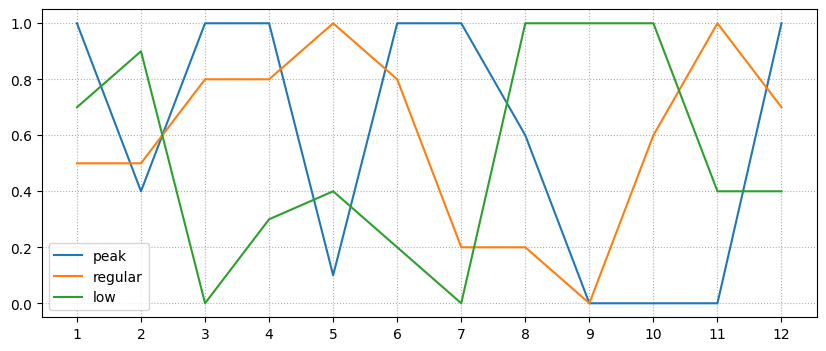

In [11]:
# Visualizar datos de temporada
(
    df_temporada_cd.drop(columns = "mes")
    .plot(figsize = [10,4])
)
plt.grid(linestyle = ":")
plt.xticks(
    ticks = range(df_temporada_cd.shape[0]), 
    labels = df_temporada_cd["mes"]
)
plt.show()

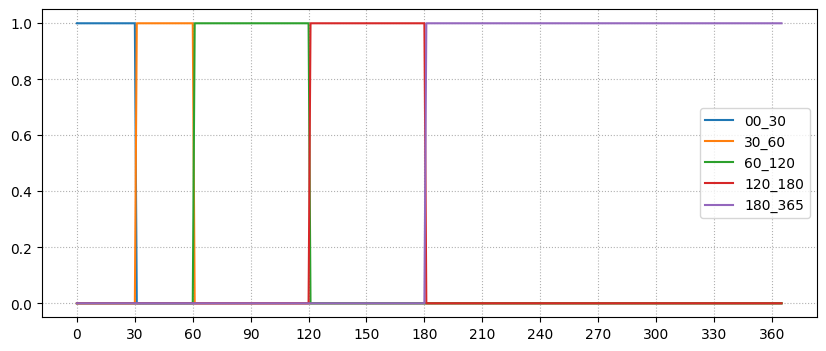

In [12]:
# Visualizar datos de dias de antelacion
(
    df_dias_cd.drop(columns = "dias")
    .plot(figsize = [10,4])
)
plt.grid(linestyle = ":")
plt.xticks(
    ticks = range(min(df_dias_cd["dias"]),
                  max(df_dias_cd["dias"]) + 1,30)
)
plt.show()

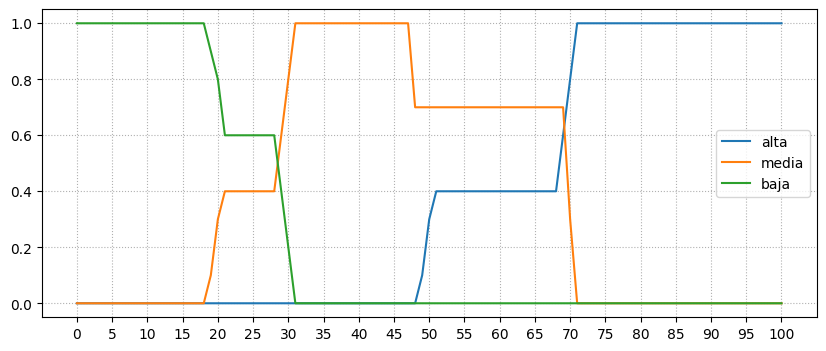

In [13]:
# Visualizar datos de nivel de disponibilidad
(
    df_disponibilidad_cd.drop(columns = "porc_disponible")
    .plot(figsize = [10,4])
)
plt.grid(linestyle = ":")
plt.xticks(
    ticks = range(min(df_disponibilidad_cd["porc_disponible"]),
                  max(df_disponibilidad_cd["porc_disponible"]) + 1,5)
)
plt.show()

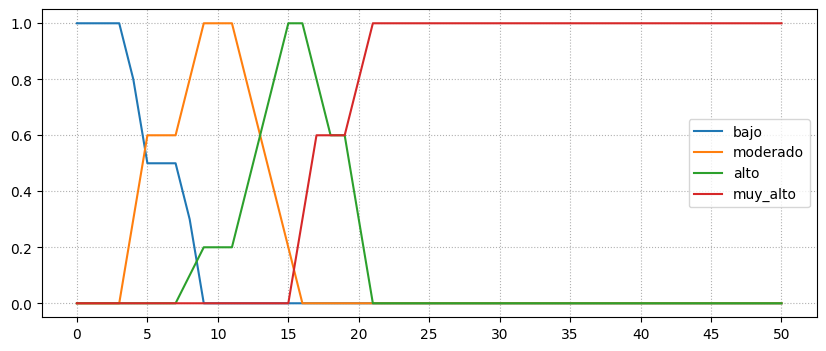

In [14]:
# Visualizar datos de nivel de descuento
(
    df_descuento_cd.drop(columns = "porc_descuento")
    .plot(figsize = [10,4])
)
plt.grid(linestyle = ":")
plt.xticks(
    ticks = range(min(df_descuento_cd["porc_descuento"]),
                  max(df_descuento_cd["porc_descuento"]) + 1,5)
)
plt.show()

Vale indicar que los valores aquí representados se interpretan como el porcentaje de ejecutivos comerciales que respondieron afirmativamente a la pregunta correspondiente. Así por ejemplo:

* Un 40% de los encuestados cree que febrero es un mes de temporada "peak".
* Un 70% considera que una disponibilidad del vuelo de 63% equivale a un nivel "medio".
* Un 60% considera que un descuento de 13% es "alto".

A todos estos atributos obtenidos los llamaremos de aquí en adelante **conjuntos difusos** o **membresías**. 

Vale señalar que toda esta información se encuentra limpia por lo que no hace falta prepararla, así que pasaremos directamente al desarrollo de nuestro modelo con **lógica difusa**, para lo cual primero introduciremos la idea detrás del algoritmo **controlador**.

## Controlador Mamdani para lógica difusa

Antes de continuar con el desarrollo de nuestro caso conviene explicar en mayor detalle cómo funcionan los modelos de **lógica difusa**. En primer lugar se necesita tener claridad que al igual que un modelo supervisado, su propósito es predecir la variable objetivo $y$ en función de atributos $X$ tal que $y = f(X)$. La gran diferencia ahora radica en que tanto $y$ como $X$ no corresponden a variables exactas o cuantificables, sino que están asociadas a los ya mencionados **conjuntos difusos**. Adicionalmente, la relación funcional descrita no es estrictamente algebráica, sino que responde a una lógica particular del contexto dada por las **reglas difusas**. Definamos entonces a la combinación de los conjuntos y las reglas difusas como nuestra **base de conocimiento**.

Visto esto, en el siguiente gráfico se muestra la idea conceptual detrás de estos modelos:

![](https://github.com/jsaraujo5081/material_curso_data_science/blob/main/complementary_files/controlador_difuso.png?raw=true)

A modo de simil, la base de conocimiento actúa como nuestro ya conocido conjunto de entrenamiento, el cual sirve como insumo para un algoritmo desarrollado por Ebhasim Mamdani. Una vez entrenado, este algoritmo puede recibir un escenario concreto de los atributos $X$ (equivalente a un conjunto de prueba) para generar una predicción de $y$.

¿Qué sucede dentro del algoritmo de Mamdani? En este momento no nos vamos a preocupar de las justificaciones teóricas que lo sustentan, pero a continuación explicamos el proceso realizado tomando como ejemplo un escenario cualquiera dado por lo siguiente:

| Atributo | Valor |
| ---- | ---- |
| Mes de viaje | 10 (Octubre) |
| Dias de anticipación | 50 |
| % de disponibilidad | 31% |

1. *Establecer los conjuntos difusos que se activan en el escenario (aquellos con un valor de membresía mayor a 0).*

In [15]:
temporada_act = df_temporada_cd.query("mes == 10")
print(temporada_act)
print()
dias_act = df_dias_cd.query("dias == 50")
print(dias_act)
print()
disponibilidad_act = df_disponibilidad_cd.query("porc_disponible == 31")
print(disponibilidad_act)

   mes  peak  regular  low
9   10   0.0      0.6  1.0

    dias  00_30  30_60  60_120  120_180  180_365
50    50      0      1       0        0        0

    porc_disponible  alta  media  baja
31               31   0.0    1.0   0.0


Quedan entonces activos los siguientes conjuntos difusos:

* Para temporada: "regular" y "low".
* Para dias de anticipación: "30_60".
* Para disponibilidad: "media".

2. *Definir las reglas que se activan por estos conjuntos (aquellas que tienen una de las opciones anteriores).*

In [16]:
reglas_act = (
    df_lineamientos
    .query("temporada == 'regular' | temporada == 'low'")
    .query("dias_de_antelacion == 'Entre 30 y 60'")
    .query("nivel_de_disponibilidad == 'media'")
)
print(reglas_act)

    lineamiento temporada dias_de_antelacion nivel_de_disponibilidad  \
19           20   regular      Entre 30 y 60                   media   
34           35       low      Entre 30 y 60                   media   

   nivel_de_descuento  
19           MODERADO  
34               ALTO  


Quedan entonces activas las reglas etiquetadas con 20 y 35.

3. *Establecer un valor referencial $\eta_r$ para cada una de las reglas activas $r$ tal que* $\eta_r = \min{(t_r, d_r, l_r)}$*, donde* 

    * $t_r$ *es el valor de membresía de la temporada en la regla.* 
    * $d_r$ *es el valor de membresía de los dias de anticipacion en la regla.* 
    * $l_r$ *es el valor de membresía del nivel de disponibilidad en la regla.*

In [17]:
eta_regla = [
    min([temporada_act["regular"].values[0], dias_act["30_60"].values[0], disponibilidad_act["media"].values[0]]),
    min([temporada_act["low"].values[0], dias_act["30_60"].values[0], disponibilidad_act["media"].values[0]])
]
reglas_act = pd.DataFrame(dict(
    regla = reglas_act["lineamiento"],
    nivel_de_descuento = reglas_act["nivel_de_descuento"],
    valor_referencial = eta_regla
))
print(reglas_act)

    regla nivel_de_descuento  valor_referencial
19     20           MODERADO                0.6
34     35               ALTO                1.0


4. *Recalcular los valores de membresía $\gamma$ de los conjuntos difusos $C$ de los niveles de descuento "moderado" y "alto" tal que*

$$ \gamma^{(n)} = \min{(\gamma, \eta_r)}\quad \forall \gamma \in C  $$

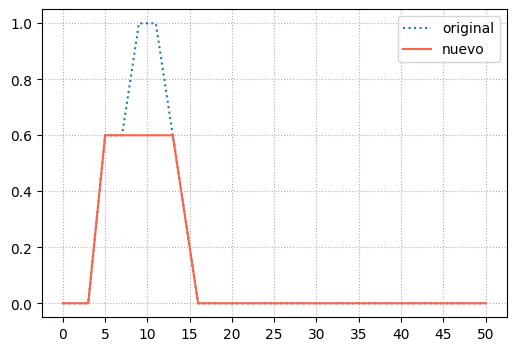

In [18]:
# Recalcular membresia de descuento moderado
cd_n_moderado = [min([reglas_act["valor_referencial"].values[0],x]) for x in df_descuento_cd["moderado"]]
plt.figure(figsize = [6,4])
plt.plot(df_descuento_cd["moderado"], linestyle = ":")
plt.plot(cd_n_moderado, color = "tomato")
plt.legend(["original", "nuevo"])
plt.grid(linestyle = ":")
plt.xticks(ticks = range(min(df_descuento_cd["porc_descuento"]),max(df_descuento_cd["porc_descuento"]) + 1,5))
plt.show()

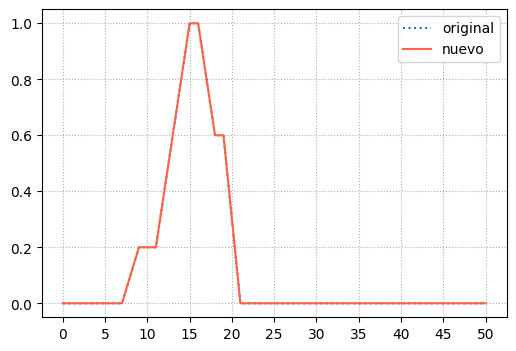

In [19]:
# Recalcular membresia de descuento alto
cd_n_alto = [min([1,x]) for x in df_descuento_cd["alto"]]
plt.figure(figsize = [6,4])
plt.plot(df_descuento_cd["alto"], linestyle = ":")
plt.plot(cd_n_alto, color = "tomato")
plt.legend(["original", "nuevo"])
plt.grid(linestyle = ":")
plt.xticks(ticks = range(min(df_descuento_cd["porc_descuento"]),max(df_descuento_cd["porc_descuento"]) + 1,5))
plt.show()

5. *Generar un conjunto difuso final $M$ tal que cada uno de sus elementos $\mu$ esté definido por*

$$ \mu = \max{\left(\gamma_{moderado}^{(n)},\gamma_{alto}^{(n)}\right)}\quad \forall \mu \in M $$

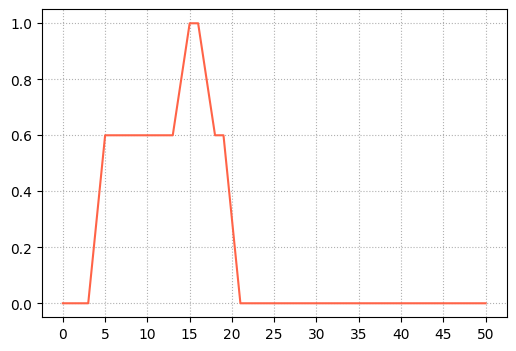

In [20]:
cd_n_final = []
for i in range(len(cd_n_moderado)):
    cd_n_final.append(max([cd_n_moderado[i], cd_n_alto[i]]))

plt.figure(figsize = [6,4])
plt.plot(cd_n_final, color = "tomato")
plt.grid(linestyle = ":")
plt.xticks(ticks = range(min(df_descuento_cd["porc_descuento"]),max(df_descuento_cd["porc_descuento"]) + 1,5))
plt.show()

6. *Calcular el porcentaje resultante de descuento $p$ como un valor central del conjunto difuso final $M$ tal que*

$$ p = \frac{\int_{M} \mu p_{\mu}}{\int_{M} \mu} \approx \frac{\sum_M \mu p_\mu}{\sum_M \mu}$$

*donde $p_\mu$ es el porcentaje de descuento asociado a $\mu$.*

Descuento pronosticado: 12.4%


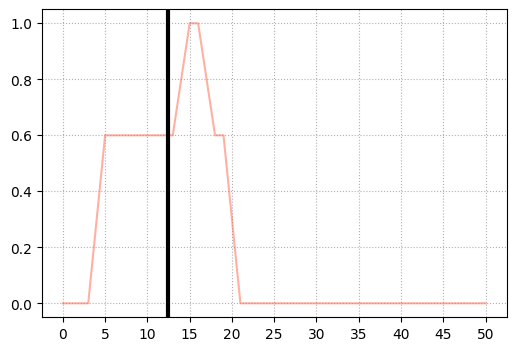

In [21]:
# Calcular descuento
descuento_final = sum(df_descuento_cd["porc_descuento"] * cd_n_final) / sum(cd_n_final)
print(f"Descuento pronosticado: {descuento_final/100:.1%}")

# Visualizar descuento
plt.figure(figsize = [6,4])
plt.plot(cd_n_final, color = "tomato", alpha = 0.5)
plt.axvline(x = descuento_final, linewidth = 3, color = "black")
plt.grid(linestyle = ":")
plt.xticks(ticks = range(min(df_descuento_cd["porc_descuento"]),max(df_descuento_cd["porc_descuento"]) + 1,5))
plt.show()

## Ingeniería de datos

Visto el proceso anterior, la librería **Scikit - Fuzzy** nos permite desarrollar este modelo de una forma más directa. Para utilizarla en todo caso, es necesario preparar estos datos tal que **Python** comprenda que estamos trabajando con conjuntos y reglas difusas.

Define entonces los atributos como conjuntos difusos mediante la función `ctrl.Antecedent`.

In [22]:
# Definir temporada como conjunto difuso
x_temp = ctrl.Antecedent(
    universe = range(min(df_temporada_cd["mes"]), max(df_temporada_cd["mes"]) + 1), 
    label = "x_temp"
)
print(x_temp)

# Definir dias de antelacion como conjunto difuso
x_dias = ctrl.Antecedent(
    universe = range(min(df_dias_cd["dias"]), max(df_dias_cd["dias"] + 1)), 
    label = "x_dias"
)
print(x_dias)

# Definir nivelde disponibilidad como conjunto difuso
x_disp = ctrl.Antecedent(
    universe = range(min(df_disponibilidad_cd["porc_disponible"]), max(df_disponibilidad_cd["porc_disponible"]) + 1), 
    label = "x_disp"
)
print(x_disp)

Antecedent: x_temp
Antecedent: x_dias
Antecedent: x_disp


Define ahora a la variable objetivo como un conjunto difuso mediante la función `ctrl.Consequent`.

In [23]:
y_desc = ctrl.Consequent(
    universe = range(min(df_descuento_cd["porc_descuento"]), max(df_descuento_cd["porc_descuento"]) + 1), 
    label = "y_desc"
)
print(y_desc)

Consequent: y_desc


Ingresa ahora los valores de membresías para estos conjuntos difusos. Para esto considera que los conjunto definidos son similares a diccionarios.

In [24]:
# Ingresar membresias para temporada
x_temp["peak"] = df_temporada_cd["peak"]
x_temp["regular"] = df_temporada_cd["regular"]
x_temp["low"] = df_temporada_cd["low"]
print(x_temp.terms)

OrderedDict({'peak': x_temp[peak], 'regular': x_temp[regular], 'low': x_temp[low]})


In [25]:
# Ingresar membresias para dias de antelacion
x_dias["00_30"] = df_dias_cd["00_30"]
x_dias["30_60"] = df_dias_cd["30_60"]
x_dias["60_120"] = df_dias_cd["60_120"]
x_dias["120_180"] = df_dias_cd["120_180"]
x_dias["180_365"] = df_dias_cd["180_365"]
print(x_dias.terms)

OrderedDict({'00_30': x_dias[00_30], '30_60': x_dias[30_60], '60_120': x_dias[60_120], '120_180': x_dias[120_180], '180_365': x_dias[180_365]})


In [26]:
# Ingresar membresias para nivel de disponibilidad
x_disp["alta"] = df_disponibilidad_cd["alta"]
x_disp["media"] = df_disponibilidad_cd["media"]
x_disp["baja"] = df_disponibilidad_cd["baja"]
print(x_disp.terms)

OrderedDict({'alta': x_disp[alta], 'media': x_disp[media], 'baja': x_disp[baja]})


In [27]:
# Ingresar membresias para nivel de descuento
y_desc["bajo"] = df_descuento_cd["bajo"]
y_desc["moderado"] = df_descuento_cd["moderado"]
y_desc["alto"] = df_descuento_cd["alto"]
y_desc["muy_alto"] = df_descuento_cd["muy_alto"]
print(y_desc.terms)

OrderedDict({'bajo': y_desc[bajo], 'moderado': y_desc[moderado], 'alto': y_desc[alto], 'muy_alto': y_desc[muy_alto]})


Define finalmente las reglas difusas para completar nuestra base de conocimiento. Utiliza la función `ctrl.Rule` y guíate por el siguiente ejemplo para la regla 1 del dataset de reglas difusas:

```py
rule_01 = ctrl.Rule(x_temp["peak"] & x_dias["00_30"] & x_disp["baja"], y_desc["moderado"])
```

In [28]:
rule_01 = ctrl.Rule(x_temp["peak"] & x_dias["00_30"] & x_disp["baja"], y_desc["moderado"])
rule_02 = ctrl.Rule(x_temp["peak"] & x_dias["00_30"] & x_disp["media"], y_desc["alto"])
rule_03 = ctrl.Rule(x_temp["peak"] & x_dias["00_30"] & x_disp["alta"], y_desc["alto"])
rule_04 = ctrl.Rule(x_temp["peak"] & x_dias["30_60"] & x_disp["baja"], y_desc["bajo"])
rule_05 = ctrl.Rule(x_temp["peak"] & x_dias["30_60"] & x_disp["media"], y_desc["moderado"])
rule_06 = ctrl.Rule(x_temp["peak"] & x_dias["30_60"] & x_disp["alta"], y_desc["moderado"])
rule_07 = ctrl.Rule(x_temp["peak"] & x_dias["60_120"] & x_disp["baja"], y_desc["bajo"])
rule_08 = ctrl.Rule(x_temp["peak"] & x_dias["60_120"] & x_disp["media"], y_desc["bajo"])
rule_09 = ctrl.Rule(x_temp["peak"] & x_dias["60_120"] & x_disp["alta"], y_desc["moderado"])
rule_10 = ctrl.Rule(x_temp["peak"] & x_dias["120_180"] & x_disp["baja"], y_desc["bajo"])
rule_11 = ctrl.Rule(x_temp["peak"] & x_dias["120_180"] & x_disp["media"], y_desc["bajo"])
rule_12 = ctrl.Rule(x_temp["peak"] & x_dias["120_180"] & x_disp["alta"], y_desc["bajo"])
rule_13 = ctrl.Rule(x_temp["peak"] & x_dias["180_365"] & x_disp["baja"], y_desc["bajo"])
rule_14 = ctrl.Rule(x_temp["peak"] & x_dias["180_365"] & x_disp["media"], y_desc["bajo"])
rule_15 = ctrl.Rule(x_temp["peak"] & x_dias["180_365"] & x_disp["alta"], y_desc["bajo"])
rule_16 = ctrl.Rule(x_temp["regular"] & x_dias["00_30"] & x_disp["baja"], y_desc["bajo"])
rule_17 = ctrl.Rule(x_temp["regular"] & x_dias["00_30"] & x_disp["media"], y_desc["moderado"])
rule_18 = ctrl.Rule(x_temp["regular"] & x_dias["00_30"] & x_disp["alta"], y_desc["alto"])
rule_19 = ctrl.Rule(x_temp["regular"] & x_dias["30_60"] & x_disp["baja"], y_desc["bajo"])
rule_20 = ctrl.Rule(x_temp["regular"] & x_dias["30_60"] & x_disp["media"], y_desc["moderado"])
rule_21 = ctrl.Rule(x_temp["regular"] & x_dias["30_60"] & x_disp["alta"], y_desc["moderado"])
rule_22 = ctrl.Rule(x_temp["regular"] & x_dias["60_120"] & x_disp["baja"], y_desc["bajo"])
rule_23 = ctrl.Rule(x_temp["regular"] & x_dias["60_120"] & x_disp["media"], y_desc["bajo"])
rule_24 = ctrl.Rule(x_temp["regular"] & x_dias["60_120"] & x_disp["alta"], y_desc["moderado"])
rule_25 = ctrl.Rule(x_temp["regular"] & x_dias["120_180"] & x_disp["baja"], y_desc["bajo"])
rule_26 = ctrl.Rule(x_temp["regular"] & x_dias["120_180"] & x_disp["media"], y_desc["bajo"])
rule_27 = ctrl.Rule(x_temp["regular"] & x_dias["120_180"] & x_disp["alta"], y_desc["moderado"])
rule_28 = ctrl.Rule(x_temp["regular"] & x_dias["180_365"] & x_disp["baja"], y_desc["bajo"])
rule_29 = ctrl.Rule(x_temp["regular"] & x_dias["180_365"] & x_disp["media"], y_desc["bajo"])
rule_30 = ctrl.Rule(x_temp["regular"] & x_dias["180_365"] & x_disp["alta"], y_desc["bajo"])
rule_31 = ctrl.Rule(x_temp["low"] & x_dias["00_30"] & x_disp["baja"], y_desc["alto"])
rule_32 = ctrl.Rule(x_temp["low"] & x_dias["00_30"] & x_disp["media"], y_desc["muy_alto"])
rule_33 = ctrl.Rule(x_temp["low"] & x_dias["00_30"] & x_disp["alta"], y_desc["muy_alto"])
rule_34 = ctrl.Rule(x_temp["low"] & x_dias["30_60"] & x_disp["baja"], y_desc["alto"])
rule_35 = ctrl.Rule(x_temp["low"] & x_dias["30_60"] & x_disp["media"], y_desc["alto"])
rule_36 = ctrl.Rule(x_temp["low"] & x_dias["30_60"] & x_disp["alta"], y_desc["muy_alto"])
rule_37 = ctrl.Rule(x_temp["low"] & x_dias["60_120"] & x_disp["baja"], y_desc["bajo"])
rule_38 = ctrl.Rule(x_temp["low"] & x_dias["60_120"] & x_disp["media"], y_desc["moderado"])
rule_39 = ctrl.Rule(x_temp["low"] & x_dias["60_120"] & x_disp["alta"], y_desc["alto"])
rule_40 = ctrl.Rule(x_temp["low"] & x_dias["120_180"] & x_disp["baja"], y_desc["bajo"])
rule_41 = ctrl.Rule(x_temp["low"] & x_dias["120_180"] & x_disp["media"], y_desc["bajo"])
rule_42 = ctrl.Rule(x_temp["low"] & x_dias["120_180"] & x_disp["alta"], y_desc["moderado"])
rule_43 = ctrl.Rule(x_temp["low"] & x_dias["180_365"] & x_disp["baja"], y_desc["bajo"])
rule_44 = ctrl.Rule(x_temp["low"] & x_dias["180_365"] & x_disp["media"], y_desc["bajo"])
rule_45 = ctrl.Rule(x_temp["low"] & x_dias["180_365"] & x_disp["alta"], y_desc["moderado"])

## Creación de modelo con lógica difusa

Crea el controlador a través de la función `ctrl.ControlSystem`. Ingresa como argumentos todas las reglas de la base de conocimiento como parte de una lista.

In [29]:
desc_controlador = ctrl.ControlSystem(
    rules = [rule_01,rule_02,rule_03,rule_04,rule_05,rule_06,rule_07,rule_08,rule_09,rule_10,
            rule_11,rule_12,rule_13,rule_14,rule_15,rule_16,rule_17,rule_18,rule_19,rule_20,
            rule_21,rule_22,rule_23,rule_24,rule_25,rule_26,rule_27,rule_28,rule_29,rule_30,
            rule_31,rule_32,rule_33,rule_34,rule_35,rule_36,rule_37,rule_38,rule_39,rule_40,
            rule_41,rule_42,rule_43,rule_44,rule_45]
)

Crea también un simulador difuso con la función `ctrl.ControlSystemSimulation` que reciba como argumento el controlador. Este simulador permitirá ejecutar los escenarios con el algoritmo de Mamdani. 

In [30]:
desc_simulador = ctrl.ControlSystemSimulation(desc_controlador)

Veamos si nuestro modelo funciona. Simula el escenario del ejemplo realizado en secciones precedentes:

| Atributo | Valor |
| ---- | ---- |
| Mes de viaje | 10 (Octubre) |
| Dias de anticipación | 50 |
| % de disponibilidad | 31% |

Utiliza en primera instancia el método `input` del simulador para asignar los valores de este escenario a los conjuntos difusos de temporada, dias de antelación y disponibilidad.

In [31]:
desc_simulador.input["x_temp"] = 10
desc_simulador.input["x_dias"] = 50
desc_simulador.input["x_disp"] = 31

Ejecuta la simulación con el método `compute`.

In [32]:
desc_simulador.compute()

Concluye obteniendo el resultado de la simulación con el método `output`.

In [33]:
# Mostrar resultado de descuento obtenido
descuento_final = desc_simulador.output["y_desc"]
print(f"Descuento sugerido: {descuento_final / 100:.1%}")

Descuento sugerido: 12.4%


Presenta el resultado de una forma más visual con el método `view` del conjunto difuso del nivel de descuento, y con el argumento `sim` igual a la variable que contiene tu simulador.

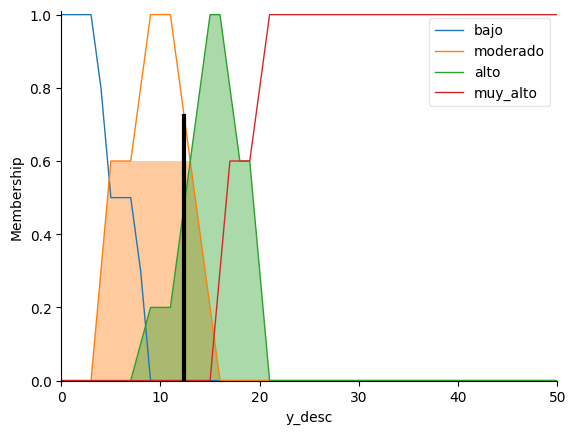

In [34]:
y_desc.view(sim = desc_simulador)

## Automatización del modelo con lógica difusa

Hagamos ahora que nuestro modelo pueda pronosticar el porcentaje de descuento para distintos escenarios de manera rápida. Crea una función que reciba como entradas valores de atributos y devuelva el valor de descuento calculado. 

In [35]:
def fun_descuento (temp, dias, disp):

    # Generar simulacion
    desc_simulador.input["x_temp"] = temp
    desc_simulador.input["x_dias"] = dias
    desc_simulador.input["x_disp"] = disp
    desc_simulador.compute()

    # Extraer descuento
    descuento_final = desc_simulador.output["y_desc"]
    return (descuento_final)

Aplica la función generada para tres escenarios distintos.

In [36]:
print(f"ESCENARIO 1 (mes de viaje: octubre, dias de anticipacion: 50, disponibilidad: 31%): {fun_descuento(10,50,31):.1f}%")
print()
print(f"ESCENARIO 2 (mes de viaje: agosto, dias de anticipacion: 55, disponibilidad: 60%): {fun_descuento(8,55,60):.1f}%")
print()
print(f"ESCENARIO 3 (mes de viaje: julio, dias de anticipacion: 120, disponibilidad: 15%): {fun_descuento(7,120,15):.1f}%")

ESCENARIO 1 (mes de viaje: octubre, dias de anticipacion: 50, disponibilidad: 31%): 12.4%

ESCENARIO 2 (mes de viaje: agosto, dias de anticipacion: 55, disponibilidad: 60%): 24.6%

ESCENARIO 3 (mes de viaje: julio, dias de anticipacion: 120, disponibilidad: 15%): 3.4%


¡Buen trabajo! La aerolinea ya cuenta con una herramienta objetiva y eficiente que le permite saber qué descuento aplicar ante distintos escenarios. Para hacerte una idea más general de su funcionalidad, en el siguiente código puedes evidenciar cómo evolucionan los descuentos calculados por el modelo ante distintos escenarios de meses y porcentajes de disponibilidad.

```py
# Generar descuentos ante distintos escenarios
mes_lista = []
disp_lista = []
desc_lista = []

for m in x_temp.universe:
    for d in x_disp.universe:
        mes_lista.append(m)
        disp_lista.append(d)
        desc_lista.append(fun_descuento(m, 90, d))

df_resultado = pd.DataFrame(dict(
    mes = mes_lista,
    disponibilidad = disp_lista,
    descuento = desc_lista
))

# Crear variables agregadas
df_resultado["trimestre"] = (df_resultado["mes"] - 1) // 3 + 1
df_resultado["grupo_disponibilidad"] = ((df_resultado["disponibilidad"] + 1) // 5) * 5

# Visualizar descuentos calculados
df_resultado.pivot_table(
    index = "grupo_disponibilidad",
    columns = "trimestre",
    values = "descuento",
    aggfunc = "median"
).style.background_gradient(cmap = "Blues", axis = None)
```

In [37]:
# Generar descuentos ante distintos escenarios
mes_lista = []
disp_lista = []
desc_lista = []

for m in x_temp.universe:
    for d in x_disp.universe:
        mes_lista.append(m)
        disp_lista.append(d)
        desc_lista.append(fun_descuento(m, 90, d))

df_resultado = pd.DataFrame(dict(
    mes = mes_lista,
    disponibilidad = disp_lista,
    descuento = desc_lista
))

# Crear variables agregadas
df_resultado["trimestre"] = (df_resultado["mes"] - 1) // 3 + 1
df_resultado["grupo_disponibilidad"] = ((df_resultado["disponibilidad"] + 1) // 5) * 5

# Visualizar descuentos calculados
df_resultado.pivot_table(
    index = "grupo_disponibilidad",
    columns = "trimestre",
    values = "descuento",
    aggfunc = "median"
).style.background_gradient(cmap = "Blues", axis = None)

trimestre,1,2,3,4
grupo_disponibilidad,,,,
0,3.404372,3.404372,3.404372,3.404372
5,3.404372,3.404372,3.404372,3.404372
10,3.404372,3.404372,3.404372,3.404372
15,3.404372,3.404372,3.404372,3.404372
20,5.871493,5.871493,5.871493,6.781362
25,6.781362,6.360511,6.781362,6.781362
30,6.642089,5.806492,7.699029,6.288066
35,6.642089,5.517436,7.699029,5.928030
40,6.642089,5.517436,7.699029,5.928030
